# Linear Regression Analysis
### In this notebook, we will perform Exploratory Data Analysis (EDA) and build both simple and multiple linear regression models using the dataset provided

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# sklearn is a library which have many important function and classes for machine learning algorithms and .model_selection is sub-module inside that and then importing train_test_split which is a funciton using to split our data into train and testing
from sklearn.linear_model import LinearRegression
# "LinerRegression" This class is the blueprint of my linear regression algorithm all the steps are given inside this for linear regression
from sklearn.metrics import mean_squared_error,r2_score
# the upper import is for evaluation

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load the dataset
df = pd.read_csv("linear_regression_data.csv")

# Display the first few rows of the dataset 
df.head()

# in the table price is the dependent variable


,MedInc,HouseAge,AveRooms,AveOccup,Latitude,Longitude,Price
0,6.243562,28,1,4,32.889897,-123.983562,411732.071058
1,14.310000,7,5,2,41.916961,-120.235850,897757.042908
2,11.247915,35,2,2,37.410029,-118.292385,668584.143344
3,9.381219,28,5,2,41.848457,-119.212951,615027.685530
4,3.184261,14,5,2,41.389964,-115.379239,335409.882746


## Exploratory Data Analysis

In [4]:
# Display basic information about the dataset
df.info()

# Summary statistics of the dataset
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MedInc     100 non-null    float64
 1   HouseAge   100 non-null    int64  
 2   AveRooms   100 non-null    int64  
 3   AveOccup   100 non-null    int64  
 4   Latitude   100 non-null    float64
 5   Longitude  100 non-null    float64
 6   Price      100 non-null    float64
dtypes: float64(4), int64(3)
memory usage: 5.6 KB


,MedInc,HouseAge,AveRooms,AveOccup,Latitude,Longitude,Price
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,8.923844,22.070000,3.480000,2.440000,39.038783,-119.542702,5.816873e+05
std,4.138767,10.607083,1.800561,1.191892,3.664171,2.862640,2.143112e+05
min,1.623755,2.000000,1.000000,1.000000,32.611433,-124.084845,2.184302e+05
25%,5.353716,11.000000,2.000000,1.000000,37.350646,-120.278875,3.989452e+05
50%,9.170566,25.000000,4.000000,2.000000,41.410679,-119.218383,6.048521e+05
75%,12.185847,31.000000,5.000000,3.000000,41.852856,-118.244948,7.083246e+05
max,16.881372,40.000000,6.000000,5.000000,42.074974,-115.100845,1.011292e+06


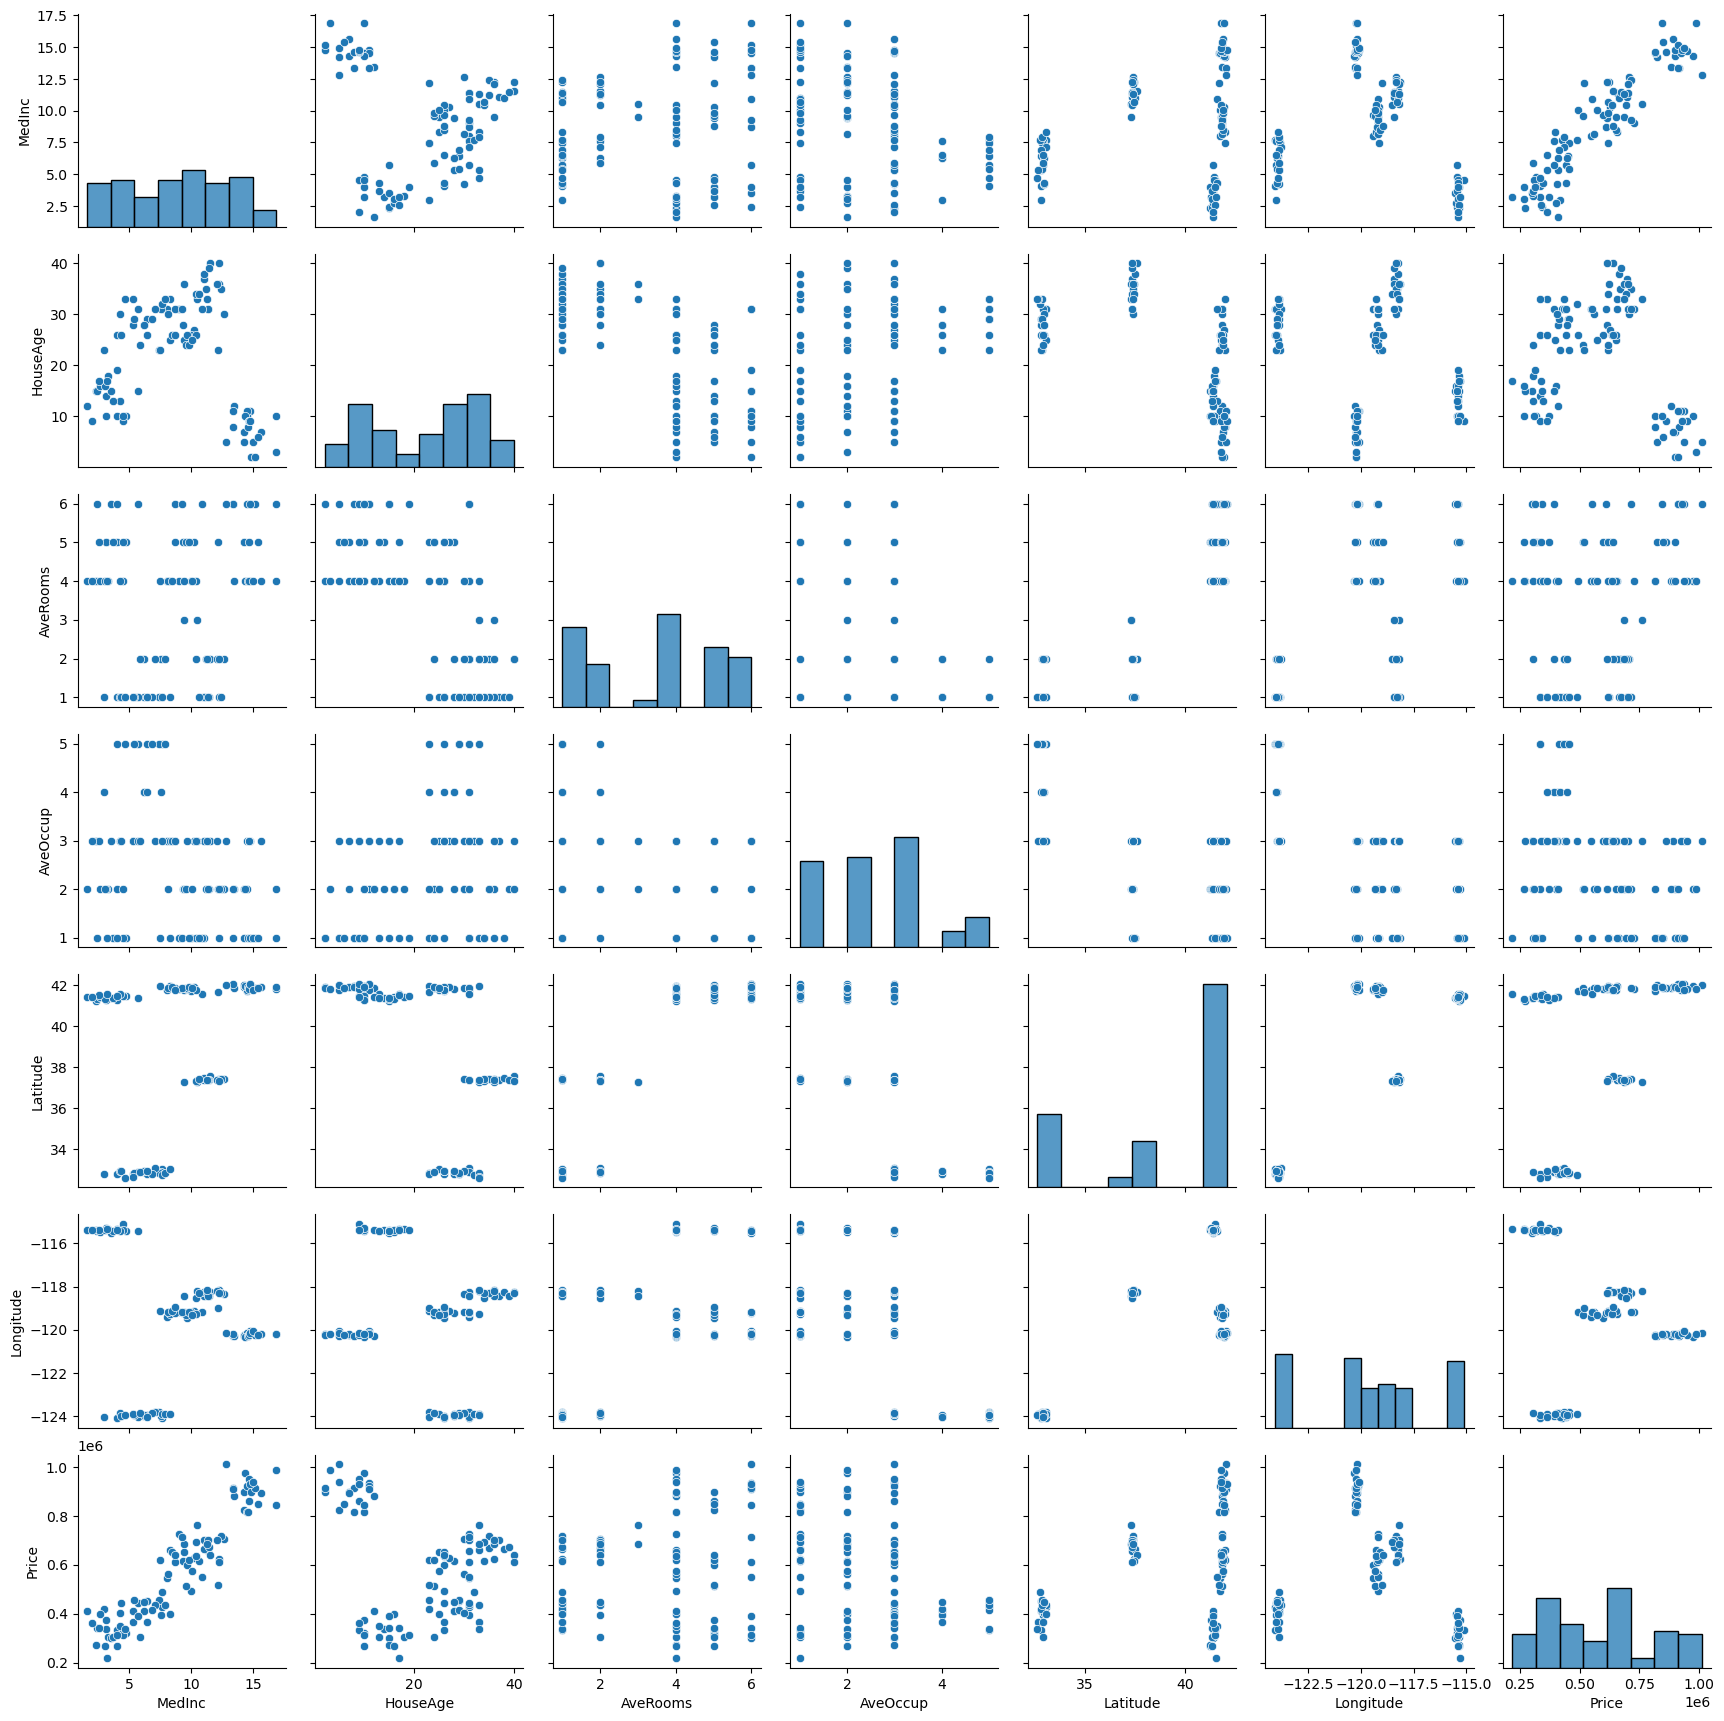

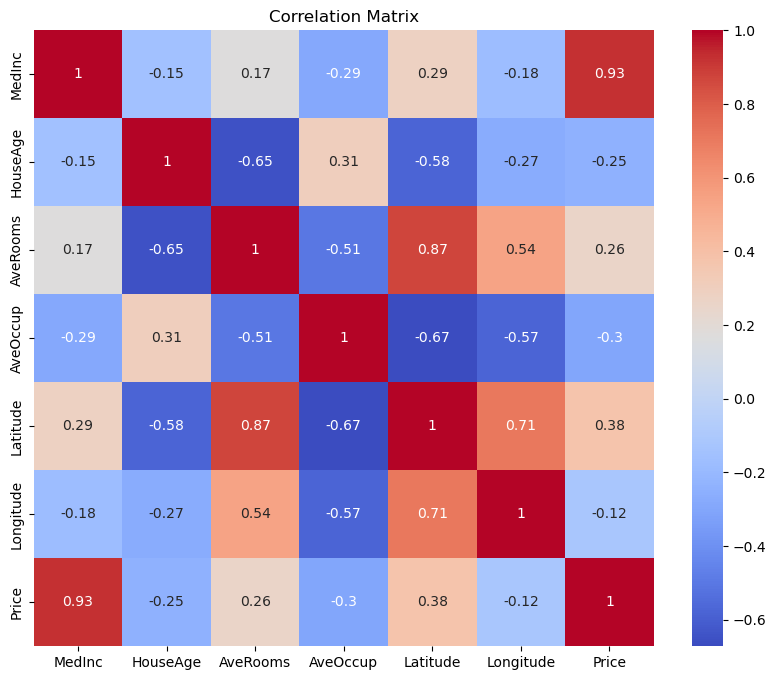

In [5]:
# Pairplot to visualize relationships between variables
sns.pairplot(df)
plt.show()

# Correlation matrix
correlation_matrix = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

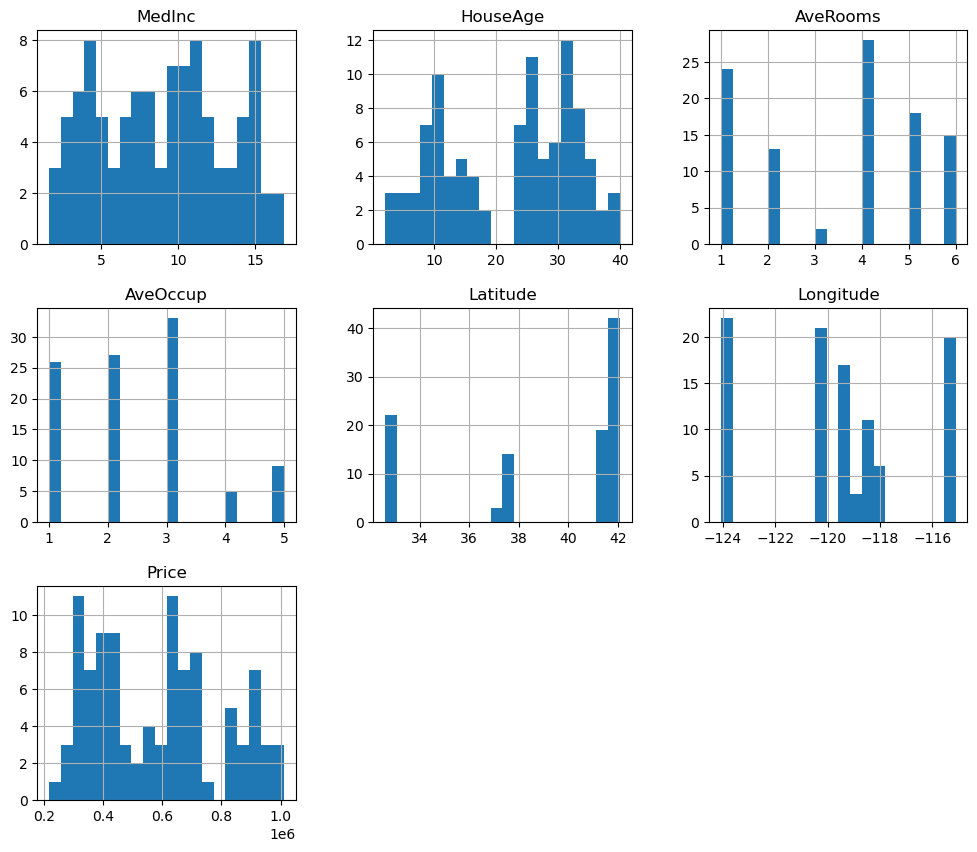

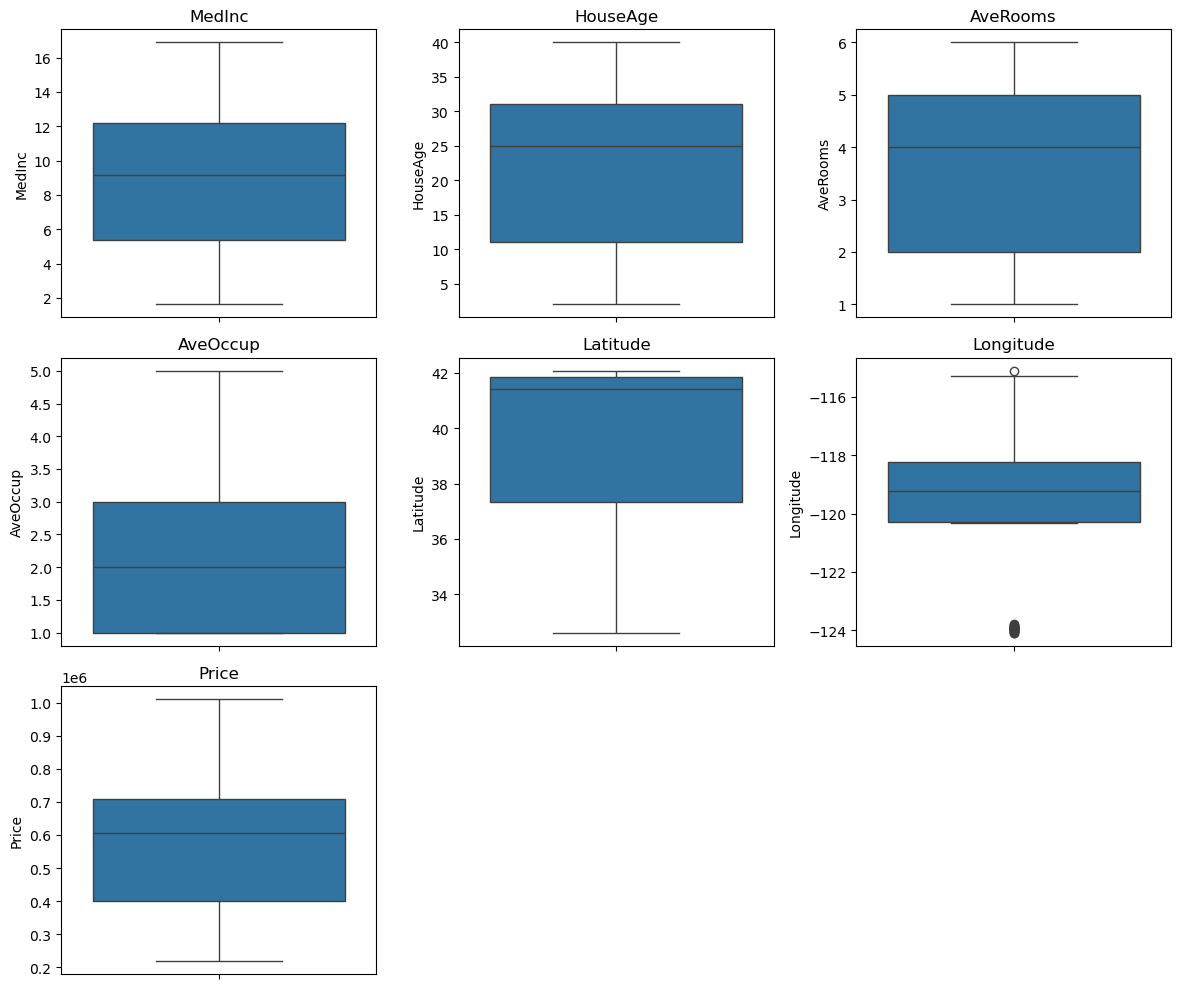

In [7]:
# Histogram of individual features
df.hist(figsize=(12,10),bins=20)
plt.show()

# Box plots to check for outliers
plt.figure(figsize=(12,10))
for i, column in enumerate(df.columns):
    plt.subplot(3,3,i+1)
    sns.boxplot(df[column])
    plt.title(column)
plt.tight_layout()
plt.show()

# Simple Linear Regression

In [9]:
# Define the target variable and the predictor variable
# Why we use the columns "MedInc" & "Target" for the linear Regression?
# ANS:- Because as we see above they form a linear Regression line so we use these columns
X = df[["MedInc"]] # Predictor and used for input 
y = df["Price"]  # Target and used for output

In [10]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
# in above "test_size=0.2" means we uses the 20% of the data to the testing set and rest 80% for training set, "random_state=42" for randomization

In [11]:
# Create and train the model
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

LinearRegression()

Mean Square Error:10877359110.17875
R^2 Score:0.7962335025791146


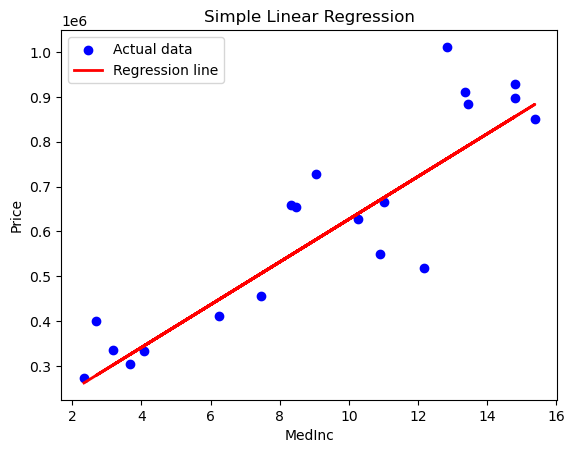

In [14]:
# Prediction
y_pred = simple_model.predict(X_test)

# Evaluate the model
print(f'Mean Square Error:{mean_squared_error(y_test, y_pred)}')
print(f'R^2 Score:{r2_score(y_test, y_pred)}')

# Plot the regression line
plt.scatter(X_test, y_test, color="blue", label="Actual data")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Regression line")
plt.xlabel("MedInc")
plt.ylabel("Price")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

In [16]:
# Assuming the model has already been trained and the relevant libraries have been imported

# Input MedInc value from the user
medinc_value = float(input("Enter the MedInc value: "))

# Converting the input to a 2D array for the model
medinc_value_array = np.array([[medinc_value]])

# Predict the house price using the trained model
predicted_price = simple_model.predict(medinc_value_array)

# Output the prediction
print(f"The predicted house price for MedInc value of {medinc_value} is: ${predicted_price[0]:.2f}")


Enter the MedInc value:  8.7


The predicted house price for MedInc value of 8.7 is: $565104.44


# Multiple Linear Regression

In [17]:
# Define multiple predictors
X_multi = df[["MedInc","HouseAge","AveRooms","AveOccup","Latitude","Longitude"]]
y_multi = df["Price"]

In [18]:
# Split the dataset into training and testing sets
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

In [19]:
# Create and train the model

multi_model = LinearRegression()
multi_model.fit(X_train_multi, y_train_multi)

LinearRegression()

In [21]:
# Prediction
y_pred_multi = multi_model.predict(X_test_multi)

# Evaluate the model
print(f'Mean Square Error:{mean_squared_error(y_test_multi, y_pred_multi)}')
print(f'R^2 Score:{r2_score(y_test_multi, y_pred_multi)}')

Mean Square Error:8672746715.630302
R^2 Score:0.8375326948975363


In [22]:
# Display the coefficients of the model
coefficients = pd.DataFrame(multi_model.coef_, X_multi.columns, columns=["Coefficient"])
print(coefficients)

            Coefficient
MedInc     44410.880445
HouseAge    -678.463779
AveRooms   -5516.145940
AveOccup    7470.171285
Latitude   13058.525818
Longitude  -6575.761317


### In this notebook, we performed exploratory data analysis, built both simple and multiple linear regression models, and evaluated their performance